# 教師あり学習 — 回帰タスク

## データセットの読み込み

In [1]:
import pandas as pd
df = pd.read_excel('boston_clean.xlsx').drop("B", axis=1)   # B は除外
display(df)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


|説明変数| 内容 |
|:-----:|:-----|
|CRIM   |犯罪率|
|ZN     |25,000 ft<sup>2</sup>を超える区画の割合|
|INDUS  |非小売業の割合|
|CHAS   |チャールズ川に接している場合は1，そうでない場合は0|
|NOX    |NOx濃度（0.1ppm単位）|
|RM     |平均部屋数|
|AGE    |1940年より前に建てられた家の割合|
|DIS    |ボストン雇用センターまでの加重距離|
|RAD    |主要高速道路へのアクセス性|
|TAX    |10,000ドル当たりの固定資産税率|
|PTRATIO|生徒と先生の比率|
|LSTAT  |低所得者人口の割合|


目的変数は住宅価格の中央値 (`MEDV`，単位は千ドル ($1,000)) である．  
この目的変数を，説明変数から推定するように学習させる．

In [2]:
import pandas as pd

#　説明変数を DataFrame にして x に代入
x = df.drop('MEDV', axis=1)

#　目的変数を Series にして y に代入
y = df['MEDV']

## データセットの概要

In [3]:
# 各変数の基本統計量の確認
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


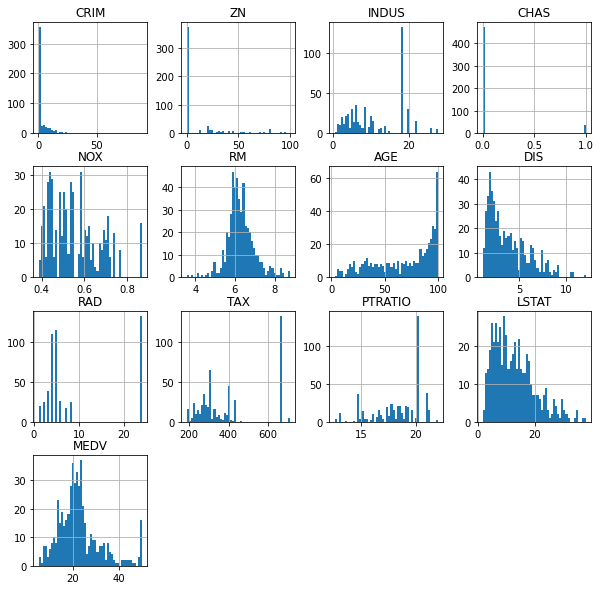

In [4]:
# 各変数のヒストグラム
import matplotlib.pyplot as plt

# binsで棒の数を多くして，figsize でグラフの大きさを大きくしている
df.hist(bins=50, figsize=(10, 10))
plt.show()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,0.543993,-0.468536


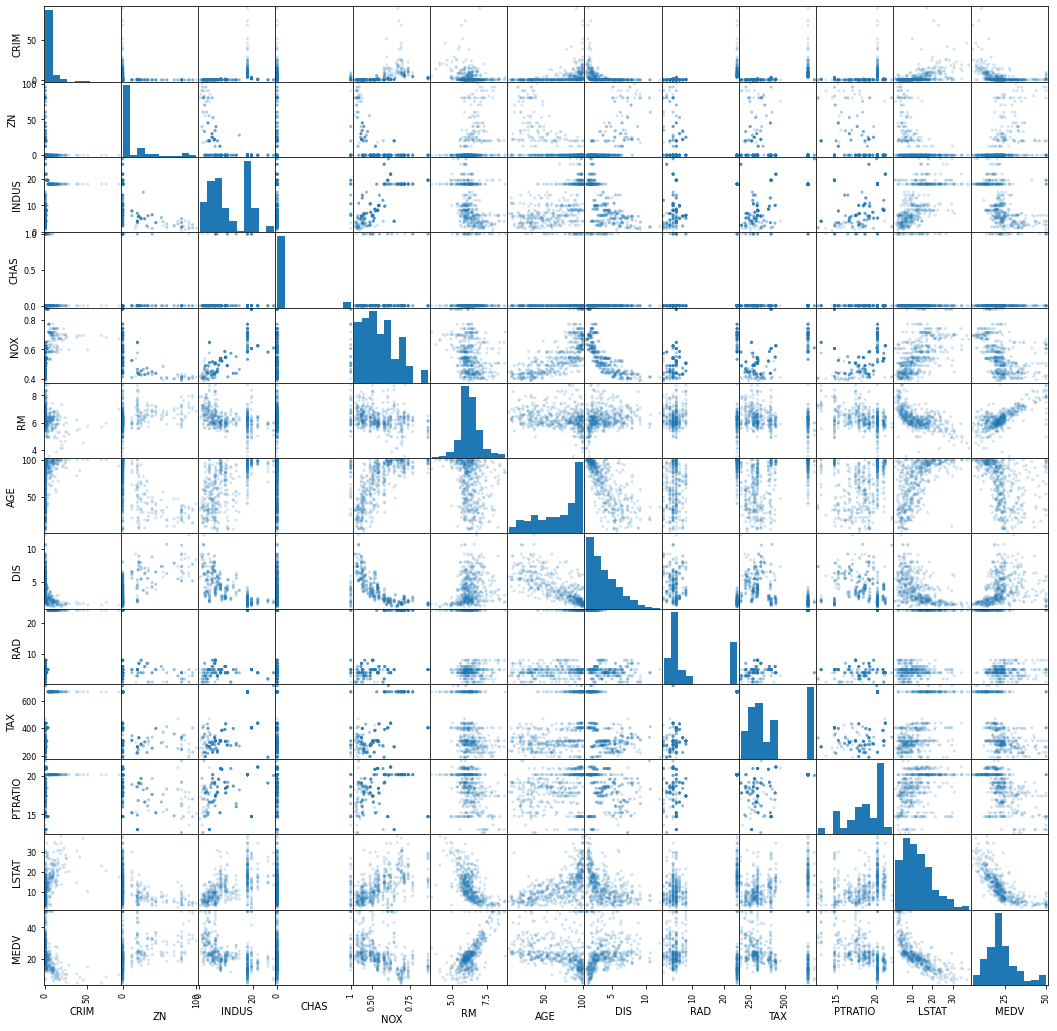

In [5]:
# 相関係数と散布図行列

# 相関係数表の表示 — 相関係数が1に近いほど強い正の相関，-1に近いほど強い負の相関，0に近いほど無相関
display(df.corr())

# 散布図行列の表示
from pandas.plotting import scatter_matrix
# figsize でグラフを大きくし，alpha でドットの透明度を上げている
sm = scatter_matrix(df, figsize=(18, 18), alpha=0.2)

## 準備 — 訓練データとテストデータの分割

<div style="margin-left:4em;">

| 変数      | 内容 |
|:--------- |:---- |
| `x_train` | 訓練データの説明変数 |
| `x_test`  | テストデータの説明変数 |
| `y_train` | 訓練データの目的変数 |
| `y_test`  | テストデータの目的変数 |
</div>

- 訓練データのサイズは全体の75%(3/4)，テストデータのサイズは全体の25%(1/4)


In [6]:
# 学習データとテストデータの分割
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

print("分割終了")

分割終了


## 単回帰分析による学習
- `RM` だけを説明変数として単回帰分析をしてみる
  $$
  \mathrm{MEDV} = A\cdot\mathrm{RM} + B\quad(A: 係数，B: 切片)
  $$
  というモデル

In [7]:
# 単回帰分析とその結果

# 説明変数を RM のみに限定
x_train1 = x_train[["RM"]]
x_test1 = x_test[["RM"]]

# LinearRegression (回帰分析) モデルを生成して訓練データを適用
from sklearn.linear_model import LinearRegression
sr_model = LinearRegression()
sr_model.fit(x_train1, y_train)

# 結果の表示
print("切片 = ", sr_model.intercept_)
display(pd.DataFrame({"変数名": x_train1.columns, "係数": sr_model.coef_}))

切片 =  -36.180992646339185


,変数名,係数
0,RM,9.312949


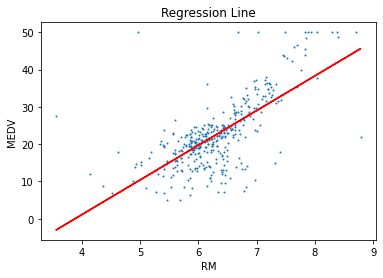

In [8]:
# グラフによる可視化
import matplotlib.pyplot as plt

plt.title("Regression Line")    # タイトル
plt.xlabel("RM")                # 横軸ラベル
plt.ylabel("MEDV")              # 縦軸ラベル

plt.scatter(x_train1, y_train, s=1, alpha=1)    # 散布図(青)
plt.plot(x_train1['RM'], sr_model.predict(x_train1), color="red")   # 回帰直線(赤)

plt.show()  # 表示

In [9]:
# 決定係数の表示
# 0 ～ 1 で，1に近いほど良い成績
print("r^2 (訓練データ):   ", sr_model.score(x_train1, y_train))
print("r^2 (テストデータ): ", sr_model.score(x_test1, y_test))

r^2 (訓練データ):    0.48752067939343646
r^2 (テストデータ):  0.4679000543136781


In [10]:
# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
sr_pred_train = sr_model.predict(x_train1)
sr_pred_test = sr_model.predict(x_test1)

# RMSEの表示
from sklearn.metrics import mean_squared_error
from math import sqrt
print("RMSE (訓練データ):   ", sqrt(mean_squared_error(y_train, sr_pred_train)))
print("RMSE (テストデータ): ", sqrt(mean_squared_error(y_test, sr_pred_test)))

RMSE (訓練データ):    6.6120122948614135
RMSE (テストデータ):  6.593333123481795


## 重回帰分析による学習
- 説明変数すべてを使って重回帰分析をしてみる
  $$
  \mathrm{MedHouseVal}=A_0\cdot\mathrm{MedInc}+\cdots+A_7\cdot\mathrm{Longitude}+B
  \quad(A_0～A_7: 係数，B: 切片)
  $$
  というモデル

In [11]:
# 重回帰分析とその結果

# 説明変数 (x_train) はすべて使用

# LinearRegression (回帰分析) モデルを生成して訓練データを適用
from sklearn.linear_model import LinearRegression
mr_model = LinearRegression()
mr_model.fit(x_train, y_train)

# 結果の表示
print("切片 = ", mr_model.intercept_)
display(pd.DataFrame({"変数名": x_train.columns, "係数": mr_model.coef_}))

切片 =  41.487899020125916


,変数名,係数
0,CRIM,-0.117016
1,ZN,0.045050
2,INDUS,-0.011376
3,CHAS,2.622898
4,NOX,-16.437406
5,RM,3.621491
6,AGE,-0.003608
7,DIS,-1.463454
8,RAD,0.214663
9,TAX,-0.011377


In [12]:
# 決定係数の表示
print("r^2 (訓練データ):   ", mr_model.score(x_train, y_train))
print("r^2 (テストデータ): ", mr_model.score(x_test, y_test))

r^2 (訓練データ):    0.7648872489912191
r^2 (テストデータ):  0.6266763285024732


In [13]:
# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
mr_pred_train = mr_model.predict(x_train)
mr_pred_test = mr_model.predict(x_test)

# RMSEの表示
from sklearn.metrics import mean_squared_error
from math import sqrt
print("RMSE (訓練データ):   ", sqrt(mean_squared_error(y_train, mr_pred_train)))
print("RMSE (テストデータ): ", sqrt(mean_squared_error(y_test, mr_pred_test)))

RMSE (訓練データ):    4.478510236624274
RMSE (テストデータ):  5.522696479172


## FNNを用いた学習

In [14]:
# FNNの学習を行う
from sklearn.neural_network import MLPRegressor
# 隠れ層のユニット数は 100 (hidden_layer_sizes= で変更可)
# max_iter で最大反復数を 800 に増加
mlp_model = MLPRegressor(random_state=0, max_iter=800)  # hidden_layer_sizes=(300,)
mlp_model.fit(x_train, y_train)

# 決定係数の表示
print("r^2 (訓練データ):   ", mlp_model.score(x_train, y_train))
print("r^2 (テストデータ): ", mlp_model.score(x_test, y_test))

r^2 (訓練データ):    0.8599839525913652
r^2 (テストデータ):  0.7057768088138212


In [15]:
# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
mlp_pred_train = mlp_model.predict(x_train)
mlp_pred_test = mlp_model.predict(x_test)

# RMSEの表示
from sklearn.metrics import mean_squared_error
from math import sqrt
print("RMSE (訓練データ):   ", sqrt(mean_squared_error(y_train, mlp_pred_train)))
print("RMSE (テストデータ): ", sqrt(mean_squared_error(y_test, mlp_pred_test)))

RMSE (訓練データ):    3.4560847718979346
RMSE (テストデータ):  4.902830309009922


## ランダムフォレストを用いた学習

In [16]:
# ランダムフォレストの学習を行う
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=0)
rf_model.fit(x_train, y_train)

# 決定係数の表示
print("r^2 (訓練データ):   ", rf_model.score(x_train, y_train))
print("r^2 (テストデータ): ", rf_model.score(x_test, y_test))

r^2 (訓練データ):    0.9821844444749239
r^2 (テストデータ):  0.7913555887425906


In [17]:
# 訓練データとテストデータにおける，
# 観測値と予測値の二乗平均平方根誤差(RMSE; 二乗誤差の平均値の平方根)の表示

# x_train1 と x_test1 に対する予測値
rf_pred_train = rf_model.predict(x_train)
rf_pred_test = rf_model.predict(x_test)

# 二乗平均平方根誤差(RMSE) — 二乗誤差の平均値の平方根
from sklearn.metrics import mean_squared_error
from math import sqrt
print("RMSE (訓練データ):   ", sqrt(mean_squared_error(y_train, rf_pred_train)))
print("RMSE (テストデータ): ", sqrt(mean_squared_error(y_test, rf_pred_test)))

RMSE (訓練データ):    1.2328072058761494
RMSE (テストデータ):  4.128685381132589


## 結果のまとめ

In [18]:
print("単回帰分析:")
print("    訓練データ:")
print("        r^2:  ", sr_model.score(x_train1, y_train))
print("        RMSE: ", sqrt(mean_squared_error(y_train, sr_pred_train)))
print("    テストデータ:")
print("        r^2:  ", sr_model.score(x_test1, y_test))
print("        RMSE: ", sqrt(mean_squared_error(y_test, sr_pred_test)))

print("重回帰分析:")
print("    訓練データ:")
print("        r^2:  ", mr_model.score(x_train, y_train))
print("        RMSE: ", sqrt(mean_squared_error(y_train, mr_pred_train)))
print("    テストデータ:")
print("        r^2:  ", mr_model.score(x_test, y_test))
print("        RMSE: ", sqrt(mean_squared_error(y_test, mr_pred_test)))

print("FNN:")
print("    訓練データ:")
print("        r^2:  ", mlp_model.score(x_train, y_train))
print("        RMSE: ", sqrt(mean_squared_error(y_train, mlp_pred_train)))
print("    テストデータ:")
print("        r^2:  ", mlp_model.score(x_test, y_test))
print("        RMSE: ", sqrt(mean_squared_error(y_test, mlp_pred_test)))

print("ランダムフォレスト:")
print("    訓練データ:")
print("        r^2:  ", rf_model.score(x_train, y_train))
print("        RMSE: ", sqrt(mean_squared_error(y_train, rf_pred_train)))
print("    テストデータ:")
print("        r^2:  ", rf_model.score(x_test, y_test))
print("        RMSE: ", sqrt(mean_squared_error(y_test, rf_pred_test)))


単回帰分析:
    訓練データ:
        r^2:   0.48752067939343646
        RMSE:  6.6120122948614135
    テストデータ:
        r^2:   0.4679000543136781
        RMSE:  6.593333123481795
重回帰分析:
    訓練データ:
        r^2:   0.7648872489912191
        RMSE:  4.478510236624274
    テストデータ:
        r^2:   0.6266763285024732
        RMSE:  5.522696479172
FNN:
    訓練データ:
        r^2:   0.8599839525913652
        RMSE:  3.4560847718979346
    テストデータ:
        r^2:   0.7057768088138212
        RMSE:  4.902830309009922
ランダムフォレスト:
    訓練データ:
        r^2:   0.9821844444749239
        RMSE:  1.2328072058761494
    テストデータ:
        r^2:   0.7913555887425906
        RMSE:  4.128685381132589
